In [1]:
# ============================================================================
# CELL 1: Import & Configuration
# ============================================================================
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import sys
sys.path.append('../../src')
import accrediff as ad
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D

In [2]:
# ============================================================================
# CELL 2: Global Parameters (Nature Style)
# ============================================================================

# ── Matplotlib Configuration ─────────────────────────
plt.rcParams.update({
    "font.family": "serif",        # Serif font
    "font.size": 12,               # Main font size
    "axes.linewidth": 1,           # Axis line width
    "axes.labelsize": 14,          # Axis label size
    "xtick.labelsize": 12,         # X-axis tick font
    "ytick.labelsize": 12,         # Y-axis tick font
    "xtick.direction": "in",       # Tick direction inward
    "ytick.direction": "in",
    "xtick.top": False,            # Remove top ticks
    "ytick.right": False,          # Remove right ticks
    "figure.dpi": 300              # High resolution
})

# ── Color Palette ────────────────────────────────────
Colors = {
    'Earth': "#1f77b4",
    'Mars': "#d62728",
    'IW15': "green",
    'IW35': "purple",
}

print("✓ Global parameters configured")

✓ Global parameters configured


# Assemble & Compare Earth/Mars Analogs

**Objective:** Aggregate and classify multiple simulation results to compare 
key parameters between Earth-like and Mars-like planetary analogs.

## Core Steps
1. Load CSV files from ./Tables folder
2. Classify by mass fraction: Earth-like (m_e: 0.7-1.3) and Mars-like (m_e: 0.05-0.3)
3. Calculate Core Mass Fraction (CMF), Mg#, and mass parameters
4. Generate comparison strip plot (scatter + mean ± error bars)
5. Export statistical results to Excel

In [3]:
# ============================================================================
# CELL 4: SECTION 1 - Data Loading
# ============================================================================

# ── File Configuration ───────────────────────────────
Path = './Tables/'  # ⭐ Modifiable parameter
file_paths = [os.path.join(Path, file_name) for file_name in sorted(os.listdir(Path)) 
              if file_name.endswith('.csv')]

# ── File Check ───────────────────────────────────────
if not file_paths:
    raise FileNotFoundError(f"No CSV files found in: {Path}")

print(f"✓ Found {len(file_paths)} CSV files in {Path}")
print()

# ── Load Data ────────────────────────────────────────
keys = [f'sim_{i+1}' for i in range(len(file_paths))]
data_dict = {}
for i, file_path in enumerate(file_paths):
    df = pd.read_csv(file_path, index_col=0)
    data_dict[keys[i]] = df

print(f"✓ Loaded: {len(data_dict)} simulation files")
print(f"  Keys: {list(data_dict.keys())[:5]}{'...' if len(data_dict) > 5 else ''}")
print()

# ── Structure Check ──────────────────────────────────
sample_key = keys[0]
sample_df = data_dict[sample_key]
print(f"Sample dataset structure ({sample_key}):")
print(f"  Rows    : {len(sample_df)}")
print(f"  Columns : {list(sample_df.columns)}")
print()

✓ Found 6 CSV files in ./Tables/

✓ Loaded: 6 simulation files
  Keys: ['sim_1', 'sim_2', 'sim_3', 'sim_4', 'sim_5']...

Sample dataset structure (sim_1):
  Rows    : 4
  Columns : ['Time', 'target_id', 'm_e', 'MgO', 'Al2O3', 'CaO', 'FeO', 'NiO', 'SiO2', 'Fe', 'Ni', 'Si', 'O']



## SECTION 2 - Data Classification

Classify simulations into two categories based on impactor mass fraction:
- **Earth analogs**: m_e between 0.7 and 1.3
- **Mars analogs**: m_e between 0.05 and 0.3
- **Others**: Remaining cases

In [4]:
# ============================================================================
# CELL 6: SECTION 2 - Data Classification
# ============================================================================

print(f"✓ Classifying by mass fraction (m_e):")
print()

# ── Add Classification Column ────────────────────────
for k, df in data_dict.items():
    if 'm_e' not in df.columns:
        raise KeyError(f"{k} missing column 'm_e'")
    
    df['Class'] = 'others'
    mask_earth = df['m_e'].between(0.7, 1.3, inclusive='both')
    mask_mars = df['m_e'].between(0.05, 0.3, inclusive='both')
    df.loc[mask_earth, 'Class'] = 'Earth_like'
    df.loc[mask_mars, 'Class'] = 'Mars_like'
    data_dict[k] = df
    
    # ── Progress Report ──────────────────────────────
    counts = df['Class'].value_counts().to_dict()
    print(f"  {k:10s}: Earth_like={counts.get('Earth_like', 0):4d} | " +
          f"Mars_like={counts.get('Mars_like', 0):4d} | " +
          f"others={counts.get('others', 0):4d}")

print()

✓ Classifying by mass fraction (m_e):

  sim_1     : Earth_like=   1 | Mars_like=   1 | others=   2
  sim_2     : Earth_like=   1 | Mars_like=   1 | others=   2
  sim_3     : Earth_like=   1 | Mars_like=   1 | others=   3
  sim_4     : Earth_like=   1 | Mars_like=   1 | others=   1
  sim_5     : Earth_like=   1 | Mars_like=   1 | others=   1
  sim_6     : Earth_like=   1 | Mars_like=   1 | others=   1



In [5]:
# ============================================================================
# CELL 7: SECTION 3 - Aggregate Classification Results
# ============================================================================

df_Earth = pd.concat([df.loc[df['Class'] == 'Earth_like'] 
                      for df in data_dict.values()], ignore_index=True)
df_Mars  = pd.concat([df.loc[df['Class'] == 'Mars_like']  
                      for df in data_dict.values()], ignore_index=True)

print(f"✓ Classification summary:")
print(f"  Earth analogs: {len(df_Earth):6d} rows")
print(f"  Mars analogs : {len(df_Mars):6d} rows")
print(f"  Total        : {len(df_Earth) + len(df_Mars):6d} rows")
print()

✓ Classification summary:
  Earth analogs:      6 rows
  Mars analogs :      6 rows
  Total        :     12 rows



## SECTION 4 - Calculate Core Parameters

Compute the following parameters:
- **Core Mass Fraction (CMF)**: Using `ad.compute_core_ratio()`
- **Mg#**: Molar Mg / (Mg + Fe) ratio in the mantle
- **Mean & Std**: Statistical summaries for each population

In [7]:
# ============================================================================
# CELL 9: SECTION 4 - Calculate CMF and Mg#
# ============================================================================

# ── Create Element Dictionary ────────────────────────
Elements = ad.constants.Elements
Elements['SiO2'] = Elements['Si'] + Elements['O'] * 2
Elements['Al2O3'] = Elements['Al']*2 + Elements['O'] * 3 
Elements['MgO'] = Elements['Mg'] + Elements['O']
Elements['FeO'] = Elements['Fe'] + Elements['O']
Elements['CaO'] = Elements['Ca'] + Elements['O']
Elements['NiO'] = Elements['Ni'] + Elements['O']

print(f"✓ Calculating CMF and Mg#:")
print()

# ── Calculate Earth CMF ──────────────────────────────
df_Earth['core_ratio'] = ad.compute_core_ratio(
    Mg_total=df_Earth['MgO'].to_numpy(),
    Al_total=df_Earth['Al2O3'].to_numpy(),
    Ca_total=df_Earth['CaO'].to_numpy(),
    x_=df_Earth['FeO'].to_numpy(),
    y_=df_Earth['NiO'].to_numpy(),
    z_=df_Earth['SiO2'].to_numpy(),
    a_=df_Earth['Fe'].to_numpy(),
    b_=df_Earth['Ni'].to_numpy(),
    c_=df_Earth['Si'].to_numpy(),
    d_=df_Earth['O'].to_numpy(),
    Elements=Elements
)

# ── Calculate Mars CMF ───────────────────────────────
df_Mars['core_ratio'] = ad.compute_core_ratio(
    Mg_total=df_Mars['MgO'].to_numpy(),
    Al_total=df_Mars['Al2O3'].to_numpy(),
    Ca_total=df_Mars['CaO'].to_numpy(),
    x_=df_Mars['FeO'].to_numpy(),
    y_=df_Mars['NiO'].to_numpy(),
    z_=df_Mars['SiO2'].to_numpy(),
    a_=df_Mars['Fe'].to_numpy(),
    b_=df_Mars['Ni'].to_numpy(),
    c_=df_Mars['Si'].to_numpy(),
    d_=df_Mars['O'].to_numpy(),
    Elements=Elements
)

# ── Calculate Mg# ────────────────────────────────────
df_Earth['Mg#'] = df_Earth['MgO'] / (df_Earth['MgO'] + df_Earth['FeO'])
df_Mars['Mg#']  = df_Mars['MgO']  / (df_Mars['MgO']  + df_Mars['FeO'])

print(f"  Earth: {len(df_Earth)} rows processed")
print(f"  Mars : {len(df_Mars)} rows processed")
print()

✓ Calculating CMF and Mg#:

  Earth: 6 rows processed
  Mars : 6 rows processed



In [8]:
# ============================================================================
# CELL 10: SECTION 5 - Add Statistical Rows
# ============================================================================

df_Earth.loc['mean'] = df_Earth.mean(numeric_only=True)
df_Earth.loc['std']  = df_Earth.std(ddof=1, numeric_only=True)

df_Mars.loc['mean'] = df_Mars.mean(numeric_only=True)
df_Mars.loc['std']  = df_Mars.std(ddof=1, numeric_only=True)

print(f"✓ Statistics added (mean & std):")
print(f"  Earth mean CMF: {df_Earth.loc['mean', 'core_ratio']:.4f}")
print(f"  Earth mean Mg#: {df_Earth.loc['mean', 'Mg#']:.4f}")
print(f"  Mars mean CMF : {df_Mars.loc['mean', 'core_ratio']:.4f}")
print(f"  Mars mean Mg# : {df_Mars.loc['mean', 'Mg#']:.4f}")
print()

✓ Statistics added (mean & std):
  Earth mean CMF: 0.2962
  Earth mean Mg#: 0.8792
  Mars mean CMF : 0.2261
  Mars mean Mg# : 0.8319



## SECTION 6 - Define Visualization Parameters

Configure strip plot layout with three metrics (CMF, Mg#, Mass):
- Reference values for Earth and Mars
- Uncertainty bands (±10%)
- Band positioning and scaling

In [9]:
# ============================================================================
# CELL 12: SECTION 6 - Parameter Definition & Data Preparation
# ============================================================================

# ── Extract Data Arrays (exclude mean & std rows) ────
mg_earth  = np.array(df_Earth['Mg#'][:-2])
mg_mars   = np.array(df_Mars['Mg#'][:-2])

mass_earth = np.array(df_Earth['m_e'][:-2])
mass_mars  = np.array(df_Mars['m_e'][:-2])

cmf_earth = np.array(df_Earth['core_ratio'][:-2])
cmf_mars  = np.array(df_Mars['core_ratio'][:-2])

# ── Reference Values ─────────────────────────────────
ref = {
    "Mass": {"Earth": 1.00, "Mars": 0.1074},
    "Mg#":  {"Earth": 0.89, "Mars": 0.775},    
    "CMF":  {"Earth": 0.32, "Mars": 0.20},
}

# ── Reference Uncertainty Bands ──────────────────────
bands_ref_range = {
    "Mass": {"Earth": (1.0, 1.0), "Mars": (0.1074, 0.1074)},
    "Mg#":  {"Earth": (0.801, 0.979), "Mars": (0.698, 0.853)},
    "CMF":  {"Earth": (0.288, 0.352), "Mars": (0.18, 0.22)},
}

# ── Tick Labels for Each Metric ──────────────────────
tick_labels = {
    "Mass": [0.2, 0.6, 1.0],
    "Mg#":  [0.80, 0.85, 0.90, 0.95],    
    "CMF":  [0.20, 0.25, 0.30, 0.35],
}

# ── Value Ranges for Normalization ───────────────────
value_range = {
    "Mass": (0.00, 1.15),
    "Mg#":  (0.75, 0.98),
    "CMF":  (0.17, 0.38),
}

# ── Band Layout Parameters ───────────────────────────
H = 1.0    # Band height
G = 0.15   # Gap between bands

band_order = ["CMF", "Mg#", "Mass"]
band_base = {name: i * (H + G) for i, name in enumerate(band_order)}

print(f"✓ Parameters initialized")
print(f"  Band height: {H}, gap: {G}")
print()

✓ Parameters initialized
  Band height: 1.0, gap: 0.15



## SECTION 7 - Helper Functions

Define three utility functions:
1. **map_to_band()**: Map data values to band coordinates
2. **_mean_std()**: Calculate mean and standard deviation
3. **draw_metric()**: Draw a single metric strip

In [10]:
# ============================================================================
# CELL 14: SECTION 7 - Define Helper Functions
# ============================================================================

def map_to_band(metric_name, v):
    """Map value to band coordinate"""
    vmin, vmax = value_range[metric_name]
    y0 = band_base[metric_name]
    return y0 + (v - vmin) / (vmax - vmin) * H

def _mean_std(a):
    """Calculate mean and standard deviation"""
    a = np.asarray(a, dtype=float)
    return float(a.mean()), float(a.std(ddof=1)) if a.size > 1 else 0.0

def draw_metric(ax, metric_name, earth_vals, mars_vals,
                color_earth="#1f77b4", color_mars="#d62728", seed=42):
    """Draw a single metric strip with data and reference values"""
    y0 = band_base[metric_name]
    
    # ── Semitransparent Reference Bands ──────────────
    e_lo, e_hi = bands_ref_range[metric_name]["Earth"]
    m_lo, m_hi = bands_ref_range[metric_name]["Mars"]
    
    ax.add_patch(Rectangle(
        (-0.40, map_to_band(metric_name, e_lo)), 0.80,
        map_to_band(metric_name, e_hi) - map_to_band(metric_name, e_lo),
        facecolor=color_earth, alpha=0.18, edgecolor="none", zorder=0
    ))
    ax.add_patch(Rectangle(
        (0.60, map_to_band(metric_name, m_lo)), 0.80,
        map_to_band(metric_name, m_hi) - map_to_band(metric_name, m_lo),
        facecolor=color_mars, alpha=0.18, edgecolor="none", zorder=0
    ))
    
    # ── Reference Dashed Lines ───────────────────────
    ax.hlines(map_to_band(metric_name, ref[metric_name]["Earth"]), -0.40, 0.40,
              linestyles="--", lw=2.5, color=color_earth, zorder=2)
    ax.hlines(map_to_band(metric_name, ref[metric_name]["Mars"]), 0.60, 1.40,
              linestyles="--", lw=2.5, color=color_mars, zorder=2)

    # ── Grid Ticklines and Labels ────────────────────
    for t in tick_labels[metric_name]:
        yy = map_to_band(metric_name, t)
        ax.hlines(yy, -0.45, 1.45, colors="0.88", linestyles="-", lw=0.6, zorder=0)
        ax.text(-0.52, yy, f"{t:g}", ha="right", va="center", 
                fontsize=14, color="0.1", fontweight="bold")

    # ── Scatter Points (with jitter) ─────────────────
    rng = np.random.default_rng(seed)
    jit_e = rng.uniform(-0.3, 0.3, size=len(earth_vals))
    jit_m = rng.uniform(-0.3, 0.3, size=len(mars_vals))
    
    ax.scatter(0 + jit_e, map_to_band(metric_name, earth_vals),
               s=55, c=color_earth, alpha=0.8, edgecolor="white", linewidth=0.5, zorder=3)
    ax.scatter(1 + jit_m, map_to_band(metric_name, mars_vals),
               s=55, c=color_mars, alpha=0.8, edgecolor="white", linewidth=0.5, zorder=3)
    
    # ── Mean ± Std Error Bars ────────────────────────
    e_mean, e_std = _mean_std(earth_vals)
    m_mean, m_std = _mean_std(mars_vals)
    
    def yerr_mapped(mean, std):
        y_c = map_to_band(metric_name, mean)
        y_lo = map_to_band(metric_name, mean - std)
        y_hi = map_to_band(metric_name, mean + std)
        return [[y_c - y_lo], [y_hi - y_c]]
    
    ax.errorbar([0], [map_to_band(metric_name, e_mean)], 
                yerr=yerr_mapped(e_mean, e_std),
                fmt="D", color="k", markersize=7, capsize=5, 
                elinewidth=1.8, capthick=1.8, zorder=4)
    ax.errorbar([1], [map_to_band(metric_name, m_mean)], 
                yerr=yerr_mapped(m_mean, m_std),
                fmt="D", color="k", markersize=7, capsize=5, 
                elinewidth=1.8, capthick=1.8, zorder=4)
    
    # ── Left Metric Label ────────────────────────────
    ax.text(-0.70, y0 + 0.5*H, metric_name, ha="right", va="center", fontsize=20)

print(f"✓ Helper functions defined")
print()

✓ Helper functions defined



## SECTION 8 - Create Strip Plot Visualization

Generate a three-metric strip plot comparing Earth and Mars analogs:
- CMF (Core Mass Fraction)
- Mg# (Magnesium number)
- Mass (Planetary mass relative to Earth)

Each metric shows:
- Scatter points with jitter (individual simulations)
- Mean ± 1σ error bars (diamonds)
- Reference bands and dashed lines

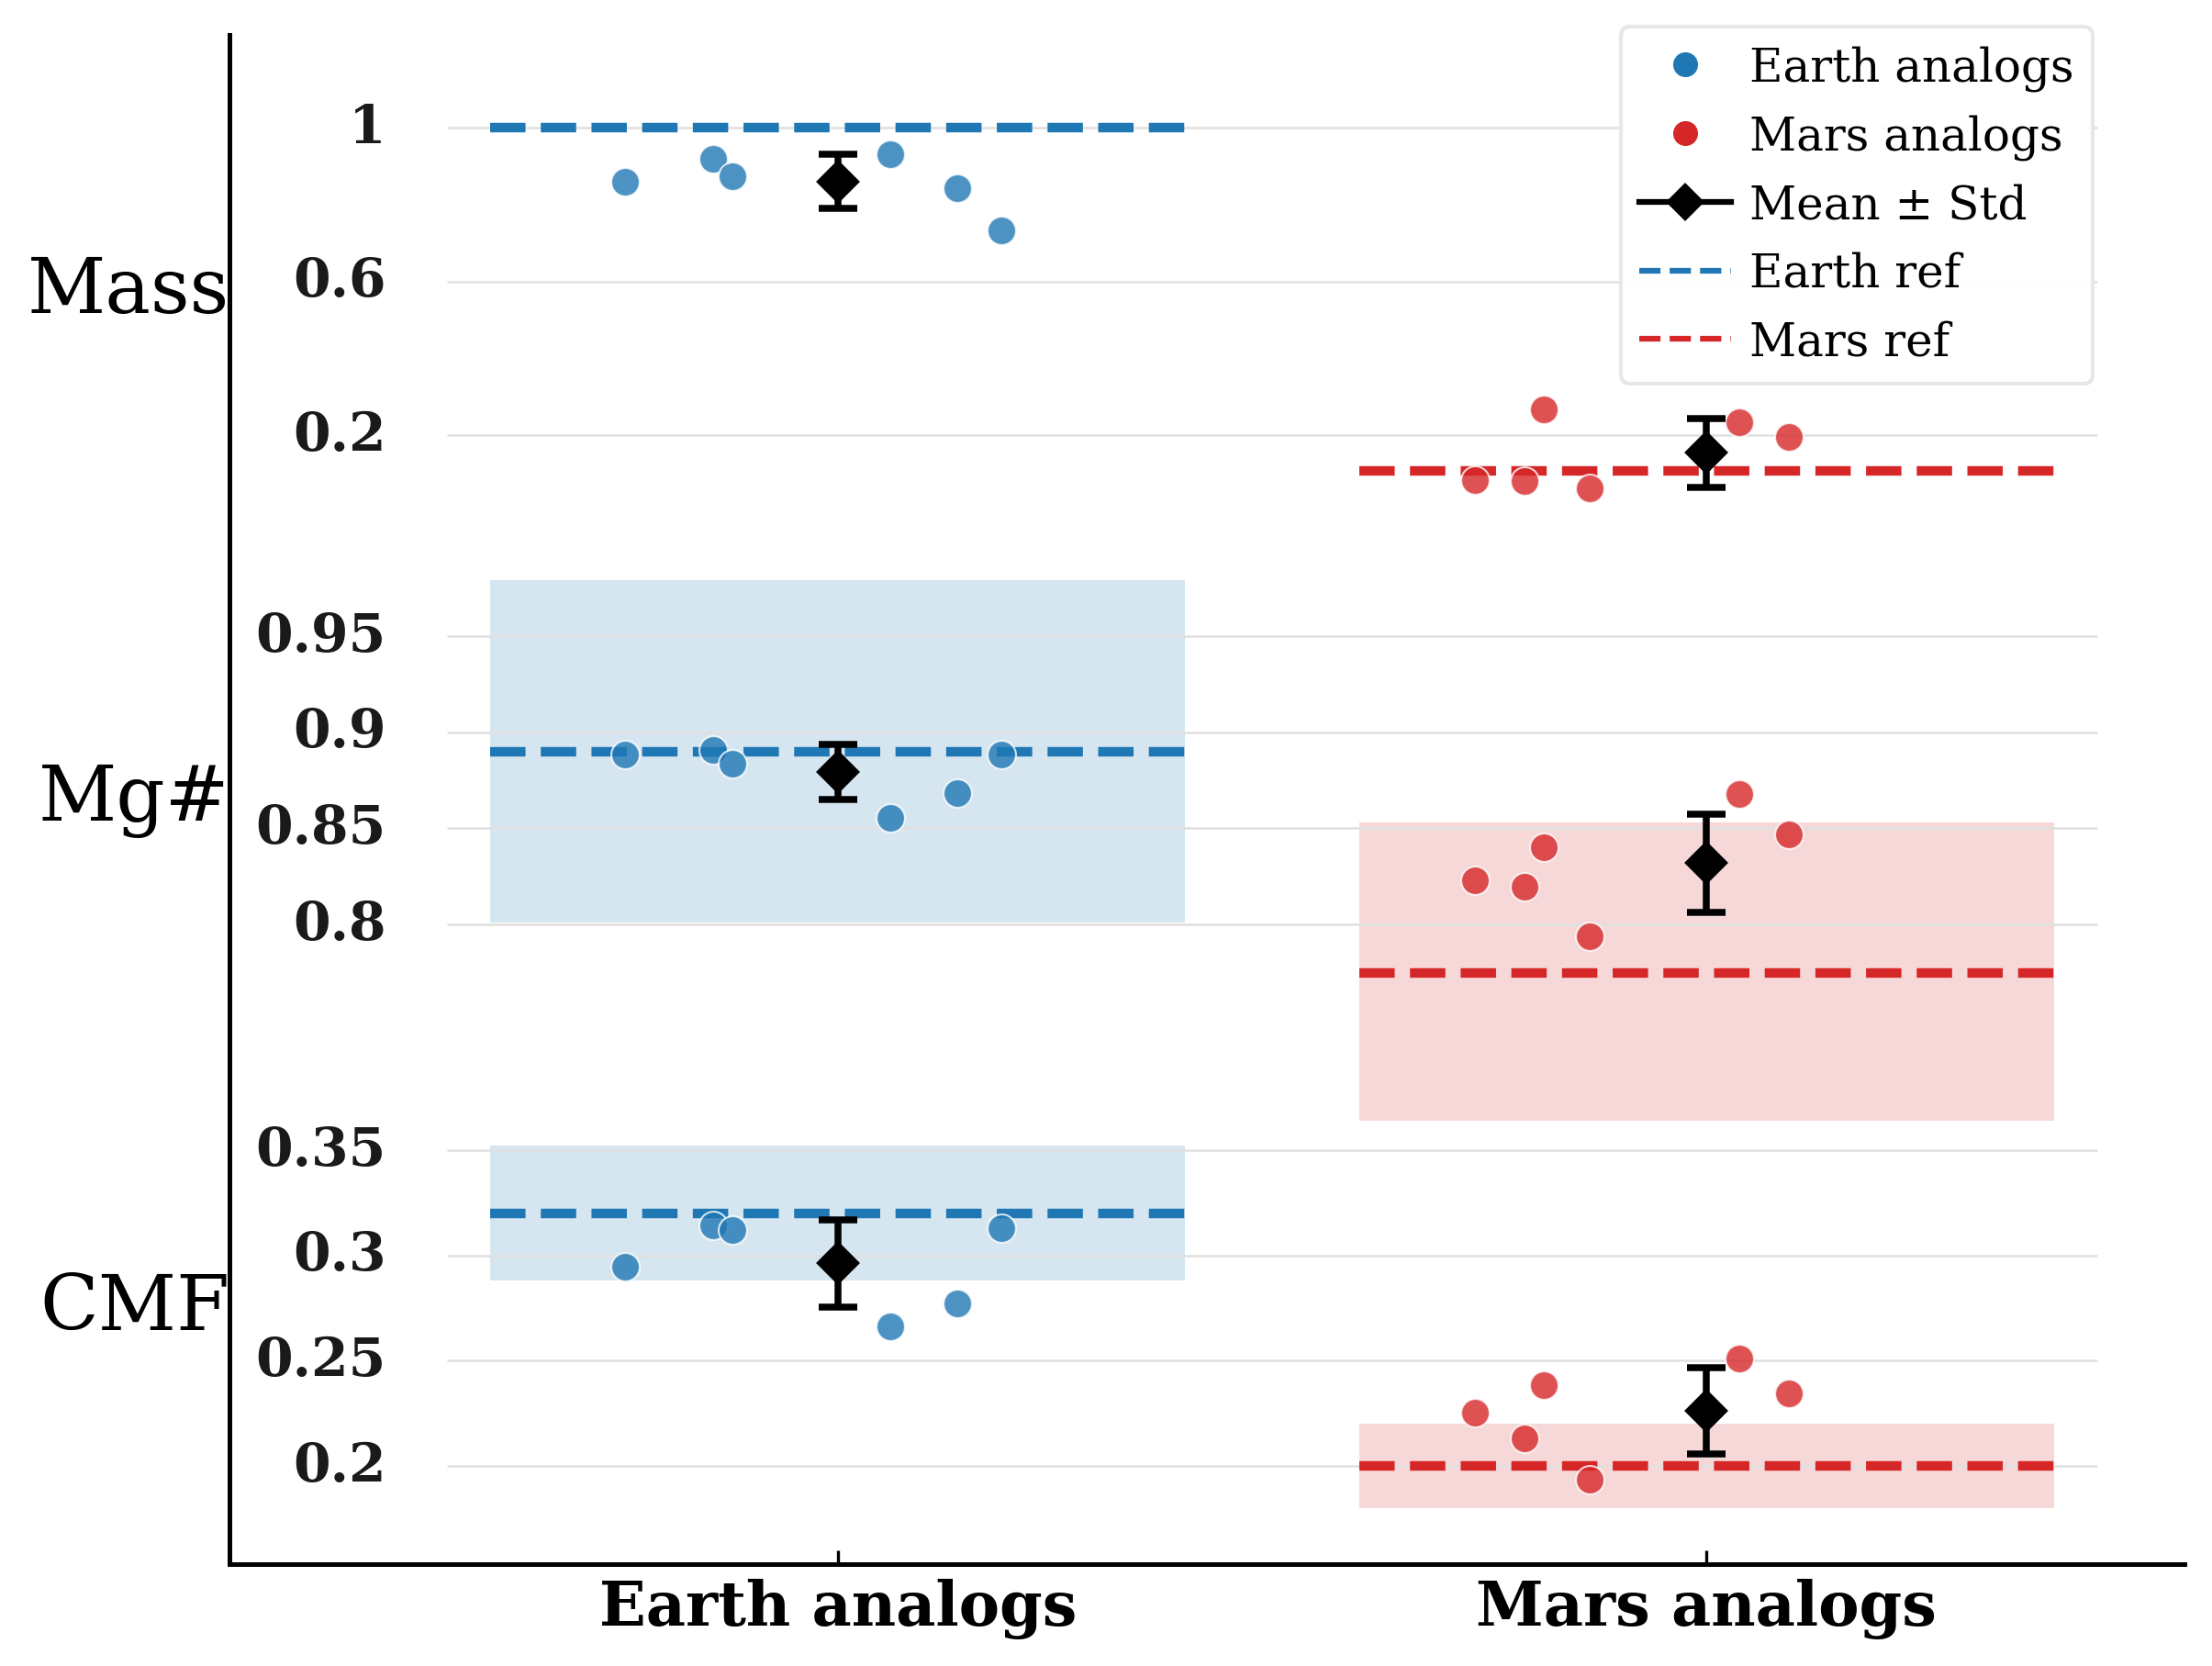

✓ Visualization displayed



In [11]:
# ============================================================================
# CELL 16: SECTION 8 - Visualization (Strip Plot)
# ============================================================================

# ── Create Figure ────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6), dpi=300)

draw_metric(ax, "CMF",  cmf_earth,  cmf_mars, seed=2)
draw_metric(ax, "Mg#",  mg_earth,   mg_mars,  seed=2)
draw_metric(ax, "Mass", mass_earth, mass_mars, seed=2)

# ── Axis Setup ───────────────────────────────────────
ax.set_xlim(-0.7, 1.55)
ax.set_xticks([0, 1])
ax.set_xticklabels(["Earth analogs", "Mars analogs"], fontsize=16, fontweight="bold")

ax.set_yticks([])
ax.set_ylabel("")

# ── Style & Appearance ───────────────────────────────
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.2)
ax.spines["bottom"].set_linewidth(1.2)

ax.set_ylim(-0.08, band_base["Mass"] + H + 0.08)

# ── Legend ───────────────────────────────────────────
handles = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#1f77b4",
           markersize=7, markeredgecolor="white", markeredgewidth=0.5, 
           label="Earth analogs"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#d62728",
           markersize=7, markeredgecolor="white", markeredgewidth=0.5, 
           label="Mars analogs"),
    Line2D([0], [0], marker="D", color="k", markersize=6, label="Mean ± Std"),
    Line2D([0], [0], linestyle="--", color="#1f77b4", lw=1.5, label="Earth ref"),
    Line2D([0], [0], linestyle="--", color="#d62728", lw=1.5, label="Mars ref"),
]

leg = ax.legend(
    handles=handles,
    loc="upper left",
    bbox_to_anchor=(0.7, 1.02),
    frameon=True,
    fontsize=12,
    borderpad=0.4,
    labelspacing=0.5,
    handletextpad=0.4,
    framealpha=0.95,
)
leg.get_frame().set_linewidth(1.0)
leg.get_frame().set_edgecolor("0.9")

plt.tight_layout(pad=0.5)
plt.show()

print(f"✓ Visualization displayed")
print()